In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from sklearn.metrics.pairwise import cosine_similarity
import faiss
import pandas as pd
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cpu


In [9]:
class TotallyLooksLikeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.pairs = []
        
        left_dir = os.path.join(root_dir, 'left')
        right_dir = os.path.join(root_dir, 'right')
        
        left_images = sorted(os.listdir(left_dir))
        for img_name in left_images:
            self.pairs.append((
                os.path.join(left_dir, img_name),
                os.path.join(right_dir, img_name),
                1  # Similar pair
            ))
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        img1_path, img2_path, label = self.pairs[idx]
        
        img1 = Image.open(img1_path).convert('RGB')
        img2 = Image.open(img2_path).convert('RGB')
        
        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)
        
        return img1, img2, torch.tensor(label, dtype=torch.float32)

In [10]:
class SiameseNetwork(nn.Module):
    def __init__(self, embedding_dim=256):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, padding=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Flatten()
        )
        self.fc = nn.Sequential(
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, embedding_dim)
        )
    
    def forward(self, x):
        x = self.cnn(x)
        x = self.fc(x)
        return F.normalize(x, p=2, dim=1)  # L2 normalized

In [11]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin
    
    def forward(self, output1, output2, label):
        euclidean_distance = F.pairwise_distance(output1, output2)
        loss = torch.mean((1 - label) * torch.pow(euclidean_distance, 2) +
                          label * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))
        return loss


# Triplet Loss is built-in in PyTorch
triplet_loss_fn = nn.TripletMarginLoss(margin=1.0, p=2)

In [12]:
def train_siamese(model, dataloader, loss_fn, optimizer, num_epochs=15, loss_type="contrastive"):
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        for img1, img2, label in tqdm(dataloader):
            img1, img2 = img1.to(device), img2.to(device)
            label = label.to(device)
            
            optimizer.zero_grad()
            emb1 = model(img1)
            emb2 = model(img2)
            
            if loss_type == "contrastive":
                loss = loss_fn(emb1, emb2, label)
            else:  # Triplet Loss (needs negative samples - simplified version)
                # For simplicity, we'll use contrastive style here. Full triplet needs careful mining.
                loss = loss_fn(emb1, emb2, emb2)  # Placeholder - replace with proper triplet mining for best results
            
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {total_loss/len(dataloader):.4f}")

In [15]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = TotallyLooksLikeDataset(root_dir="/home/saidul/Desktop/4-2/Deep Learning/data/Totally_Looks_Like", transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Train Contrastive Model
model_contrastive = SiameseNetwork().to(device)
optimizer_c = torch.optim.Adam(model_contrastive.parameters(), lr=0.001)
contrastive_loss = ContrastiveLoss(margin=1.0)

print("Training with Contrastive Loss...")
train_siamese(model_contrastive, dataloader, contrastive_loss, optimizer_c, num_epochs=5, loss_type="contrastive")

# Train Triplet Model
model_triplet = SiameseNetwork().to(device)
optimizer_t = torch.optim.Adam(model_triplet.parameters(), lr=0.001)

print("Training with Triplet Loss...")
train_siamese(model_triplet, dataloader, triplet_loss_fn, optimizer_t, num_epochs=5, loss_type="triplet")

Training with Contrastive Loss...


100%|██████████| 188/188 [05:01<00:00,  1.60s/it]


Epoch [1/5] - Loss: 0.0405


100%|██████████| 188/188 [04:14<00:00,  1.35s/it]


Epoch [2/5] - Loss: 0.0084


...

Epoch [3/5] - Loss: 1.0000


100%|██████████| 188/188 [04:31<00:00,  1.44s/it]


Epoch [4/5] - Loss: 1.0000


100%|██████████| 188/188 [04:29<00:00,  1.43s/it]

Epoch [5/5] - Loss: 1.0000


In [37]:
def build_embedding_database(model, dataset):
    model.eval()
    embeddings = []
    image_paths = []
    
    with torch.no_grad():
        for i in range(len(dataset)):
            img1, _, _ = dataset[i]
            img1 = img1.unsqueeze(0).to(device)
            emb = model(img1)
            embeddings.append(emb.cpu().numpy())
            image_paths.append(dataset.pairs[i][0])  # left image path
    
    embeddings = np.vstack(embeddings)
    return embeddings, image_paths



In [40]:
# Build index
embeddings_triplet, paths_triplet = build_embedding_database(model_triplet, dataset)  # Use best model
index_triplet = faiss.IndexFlatL2(embeddings_triplet.shape[1])
index_triplet.add(embeddings_triplet)

embeddings_contrastive, paths_contrastive = build_embedding_database(model_contrastive, dataset)  # Use best model
index_contrastive = faiss.IndexFlatL2(embeddings_contrastive.shape[1])
index_contrastive.add(embeddings_contrastive)

In [41]:
def search_similar(query_image_path, model, model_name, index, paths, k=5):
    model.eval()
    img = Image.open(query_image_path).convert('RGB')
    img = transform(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        query_emb = model(img).cpu().numpy()
    
    D, I = index.search(query_emb, k)
    
    plt.figure(figsize=(15, 3))
    plt.suptitle(f"Top {k} similar images using {model_name}", fontsize=16)
    plt.subplot(1, k+1, 1)
    plt.imshow(Image.open(query_image_path))
    plt.title("Query")
    plt.axis('off')
    
    for i in range(k):
        plt.subplot(1, k+1, i+2)
        plt.imshow(Image.open(paths[I[0][i]]))
        plt.title(f"Rank {i+1}")
        plt.axis('off')
    plt.show()

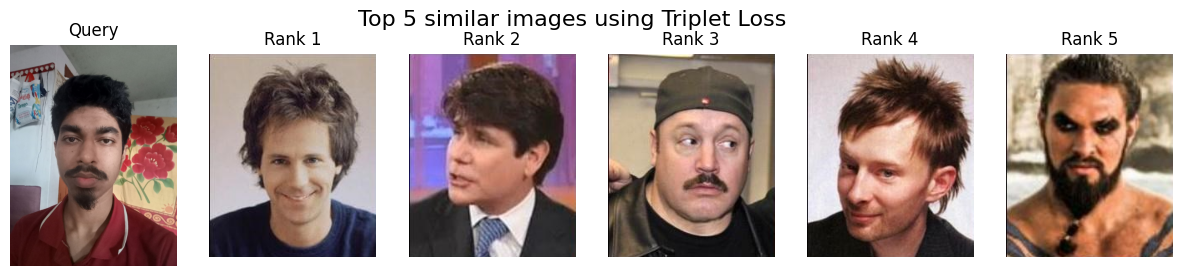

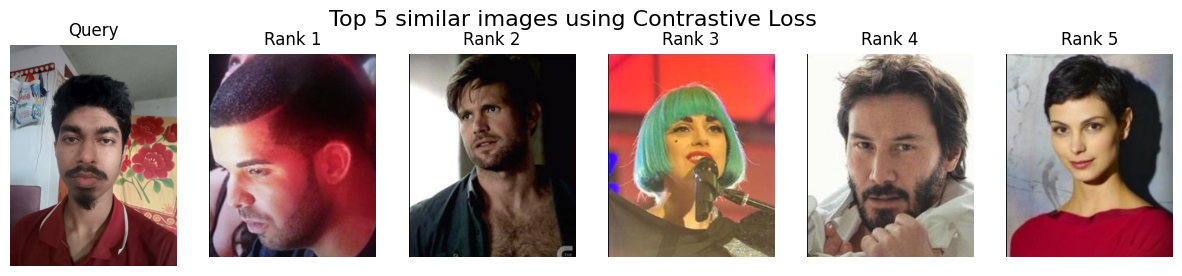

In [49]:
# Test with any image from the dataset (left folder)
test_query_path = "/home/saidul/Desktop/4-2/Deep Learning/data/faces/person_0/Saidul_0.jpg"   # ← CHANGE THIS

search_similar(
    query_image_path=test_query_path,
    model=model_triplet,          # or model_contrastive
    model_name="Triplet Loss",
    index=index_triplet,
    paths=paths_triplet,
    k=5
)

search_similar(
    query_image_path=test_query_path,
    model=model_contrastive,          # or model_triplet
    model_name="Contrastive Loss",
    index=index_contrastive,
    paths=paths_contrastive,
    k=5
)